# Value at Risk (VaR) on a swaps Portfolio using Covariance Matrix

##### Imports

In [80]:
%load_ext autoreload
%autoreload 2

import sys
import os
# Adds the parent directory to the path so 'core' is visible
sys.path.append(os.path.abspath(".."))

from core.solvedcurve import SolvedCurve
from core.swap import Swap 
from core.dual import Dual 
from datetime import datetime, timedelta
from core.portfolio import Portfolio

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
from core.solvedcurve import SolvedCurve
from core.swap import Swap 
from core.dual import Dual 
from datetime import datetime, timedelta
from core.portfolio import Portfolio

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Setup a SolvedCurve and caliberate

In [81]:
nodes = {
    datetime(2022, 1, 1): Dual(1, {"v0": 1}),
    datetime(2024, 1, 1): Dual(1, {"v1": 1}),
    datetime(2027, 1, 1): Dual(1, {"v2": 1}),
    datetime(2032, 1, 1): Dual(1, {"v3": 1}),
    datetime(2052, 1, 1): Dual(1, {"v4": 1}),
}
swaps = {
    Swap(datetime(2022, 1, 1), 12*2, 12, 12): 1.20,
    Swap(datetime(2022, 1, 1), 12*5, 12, 12): 1.66,
    Swap(datetime(2022, 1, 1), 12*10, 12, 12): 1.93,
    Swap(datetime(2022, 1, 1), 12*30, 12, 12): 2.20,
}
s_cv = SolvedCurve(nodes=nodes, interpolation="log_linear", swaps=list(swaps.keys()), obj_rates=list(swaps.values()))
s_cv.iterate()

'tolerance reached (levenberg_marquardt) after 12 iterations. f:1.43219494212483e-18'

### Build covariance matrix using Historical data

In [82]:
historical_rates = pd.DataFrame({
    "2Y": [1.199, 1.228, 1.210, 1.215, 1.203, 1.159, 1.175, 1.188, 1.159, 1.100],
    "5Y": [1.663, 1.696, 1.665, 1.680, 1.677, 1.657, 1.673, 1.676, 1.653, 1.600],
    "10Y": [1.928, 1.945, 1.934, 1.93, 1.934, 1.931, 1.958, 1.972, 1.932, 1.900],
    "30Y": [2.201, 2.217, 2.228, 2.239, 2.226, 2.235, 2.242, 2.236, 2.22, 2.200],
})
historical_rates

,2Y,5Y,10Y,30Y
0,1.199,1.663,1.928,2.201
1,1.228,1.696,1.945,2.217
2,1.210,1.665,1.934,2.228
3,1.215,1.680,1.930,2.239
4,1.203,1.677,1.934,2.226
5,1.159,1.657,1.931,2.235
6,1.175,1.673,1.958,2.242
7,1.188,1.676,1.972,2.236
8,1.159,1.653,1.932,2.220
9,1.100,1.600,1.900,2.200


In [83]:
daily_changes_bp = historical_rates.diff(periods=-1) * 100
daily_changes_bp

,2Y,5Y,10Y,30Y
0,-2.9,-3.3,-1.7,-1.6
1,1.8,3.1,1.1,-1.1
2,-0.5,-1.5,0.4,-1.1
3,1.2,0.3,-0.4,1.3
4,4.4,2.0,0.3,-0.9
5,-1.6,-1.6,-2.7,-0.7
6,-1.3,-0.3,-1.4,0.6
7,2.9,2.3,4.0,1.6
8,5.9,5.3,3.2,2.0
9,NaN,NaN,NaN,NaN


In [84]:
Q = daily_changes_bp.cov().to_numpy()
Q

array([[8.66      , 7.3775    , 5.13625   , 2.185     ],
       [7.3775    , 7.3075    , 4.73      , 2.1575    ],
       [5.13625   , 4.73      , 4.89111111, 1.76236111],
       [2.185     , 2.1575    , 1.76236111, 1.86111111]])

### Create a portfolio and calculate portfolio loss for different confidence intervals

In [85]:
swaps = [
    Swap(datetime(2022, 1, 1), 12 * 2, 12, 12, fixed_rate=1.20, notional=-50.9e6),
    Swap(datetime(2022, 1, 1), 12 * 5, 12, 12, fixed_rate=1.66, notional=5.23e6),
    Swap(datetime(2022, 1, 1), 12 * 10, 12, 12, fixed_rate=1.93, notional=11.0e6),
    Swap(datetime(2022, 1, 1), 12 * 30, 12, 12, fixed_rate=2.20, notional=-1.81e6),
]

portfolio = Portfolio(objects=swaps)
print(f'{portfolio.npv(s_cv).real=}')
print(f'{portfolio.risk(s_cv).real=}')

c = portfolio.covar(s_cv, Q)
print(f'Portfolio standard deviation: {c=}')

portfolio.npv(s_cv).real=0.0006245420787580247
portfolio.risk(s_cv).real=array([[-9999.50687339],
       [ 2501.9760912 ],
       [10005.96573679],
       [-3998.1359313 ]])
Portfolio standard deviation: c=16171.26796643079


### Portfolio loss for few confidence intervals (Assuming normal distribution with u=0 for price changes)

In [86]:
key_x = [50, 84.13447, 90, 95, 99]
key_y = [portfolio.covar(s_cv, Q, alpha=(1-xi/100)) for xi in key_x]

for x, covar_x in zip(key_x, key_y):
    print(f'{x}% of the time loss <= {covar_x}')

50% of the time loss <= 0.0
84.13447% of the time loss <= 16171.264887600966
90% of the time loss <= 20724.313779220625
95% of the time loss <= 26599.368766987845
99% of the time loss <= 37619.99485425102


### Plot portfolio change with confidence interval

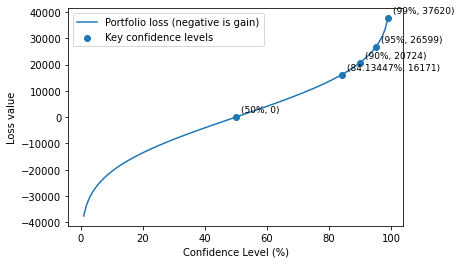

In [87]:
x = [i for i in range(0, 100)]
y = [portfolio.covar(s_cv, Q, alpha=(1-xi/100)) for xi in x]

# annotate key_x, covar values
for xi, covar_x in zip(key_x, key_y):
    plt.annotate(f'({xi}%, {covar_x:.0f})', 
                 xy=(xi, covar_x), 
                 xytext=(5, 5), 
                 textcoords='offset points',
                 fontsize=9)

plt.plot(np.array(x), np.array(y), label='Portfolio loss (negative is gain)')
plt.scatter(key_x, key_y, label='Key confidence levels')

plt.xlabel('Confidence Level (%)')
plt.ylabel('Loss value')


plt.legend()
plt.show()

### Single instrument Var Minimisation

We try to find the Risk to execute in one instrument to minimise the Value at Risk (VaR) while keeping all other positions unchanged

standard deviation of the portfolio, c = sqrt(S_T . Q . S)
where
    - Si is the column vector of portfolio NPV sensitivities to each pillar
    - Q is the covariance matrix, qij = E(Xi. Xj) where Xi, Xj are the daily bp changes in instrument i,j

dc / dS = 1/(2 . sqrt(S_T . Q . S)) * (Q + Q_T) . S

dc / dS = 1/(2c) * (2Q) . S (since Q is symmetric, qij = qji)

(dc / dS) = (1/c) * (Q.S)

c.(dc/dS) = Q.S 

Here, Q.S is the risk (scaled) attributed to each instrument. 

The opposite risk to trade for ith instrument to minimise Var

S_i_trade = (-1/Q[i,i]) . Q . S = (-1/Q[i,i]) . c . (dc/dS)

in matrix computation
S_trade = diag(diagonal(Q))^-1 .Q.S

In [88]:
print('Single instrument var minimising trades, S_trade=')
S_trade = portfolio.covar_smt(s_cv, Q)
print(S_trade, '\n')

print('Exposure in each instrument S=')
S = portfolio.risk(s_cv)
print(S, '\n')

print('Overall desired risk position in individual instrument to minimize VaR wrt. other individual positions remaining the same')
print(S_trade + S)

Single instrument var minimising trades, S_trade=
[[2942.28480428]
 [2297.08272443]
 [-484.24797341]
 [3362.3781923 ]] 

Exposure in each instrument S=
[[-9999.50687339]
 [ 2501.9760912 ]
 [10005.96573679]
 [-3998.1359313 ]] 

Overall desired risk position in individual instrument to minimize VaR wrt. other individual positions remaining the same
[[-7057.22206911]
 [ 4799.05881563]
 [ 9521.71776338]
 [ -635.757739  ]]


## Impact of executing the i'th Single instrument VaR minimising trade

In [89]:
print('c_i - c values assuming we execute the ith VaR minimising trade keeping all other risks unchanged')
c_impact = portfolio.covar_smt_impact(s_cv, Q)
c_impact

c_i - c values assuming we execute the ith VaR minimising trade keeping all other risks unchanged


array([[-2513.30536682],
       [-1239.7163655 ],
       [  -35.5014472 ],
       [ -664.20654727]])

In [90]:
print("Percentage reductions by any single trade")
c_impact * 100 / c 

Percentage reductions by any single trade


array([[-15.54179531],
       [ -7.66616674],
       [ -0.2195341 ],
       [ -4.10732509]])

Above results show that the maximum reduction in Var is 16% by executing a trade in a single instrument, instrument 0. And the risk to be traded is S_trade[0] = 2935 PV01

## Allocation of VaR into individual risk buckets

In [91]:
print(f'{c=}')
portfolio.covar_alloc(s_cv, Q)

c=16171.26796643079


array([[15755.67850469],
       [-2597.07529685],
       [ 1465.51503525],
       [ 1547.14972334]])

## Visualizing it together

In [92]:
df = pd.DataFrame(
    index=["2Y", "5Y", "10Y", "30Y"],
    data={
        "S": portfolio.risk(s_cv)[:, 0],
        "S_trade": portfolio.covar_smt(s_cv, Q)[:, 0],
        "c_impact": portfolio.covar_smt_impact(s_cv, Q)[:, 0],
        "%": portfolio.covar_smt_impact(s_cv, Q)[:, 0] / portfolio.covar(s_cv, Q) * 100,
        "VaR alloc": portfolio.covar_alloc(s_cv, Q)[:, 0]
    }
)
df.style.format("{:,.0f}")

,S,S_trade,c_impact,%,VaR alloc
2Y,"-10,000","2,942","-2,513",-16,"15,756"
5Y,"2,502","2,297","-1,240",-8,"-2,597"
10Y,"10,006",-484,-36,-0,"1,466"
30Y,"-3,998","3,362",-664,-4,"1,547"


## Multi instrument VaR minimisation
We select a subset of instruments and try to minimize VaR and measure the c_impact for those 

In [93]:
print('VaR minimization by trading only 2Y and 10Y instruments')
print('Risk to trade in 2Y, 10Y buckets = \n', portfolio.covar_mmt(s_cv, Q, [0, 2]))
print()
print('Impact on portfolio c due to these trades')
portfolio.covar_mmt_impact(s_cv, Q, [0, 2])

VaR minimization by trading only 2Y and 10Y instruments
Risk to trade in 2Y, 10Y buckets = 
 [[ 8562.34626197]
 [    0.        ]
 [-9475.7327279 ]
 [    0.        ]]

Impact on portfolio c due to these trades


-11600.014855555208

### 2 instrument VaR minimising trades

In [94]:
combinations = [(0, 1), (0,2), (0,3), (1, 2), (1, 3), (2, 3)]
tenors = ['2Y', '5Y', '10Y', '30Y']
df_mmt = pd.DataFrame(index=tenors)
c = portfolio.covar(s_cv, Q)
for combo in combinations: 
    df_mmt.loc[tenors, f'{combo}'] = portfolio.covar_mmt(s_cv, Q, list(combo))[:, 0]
    df_mmt.loc['impact', f'{combo}'] = portfolio.covar_mmt_impact(s_cv, Q, list(combo))

df_mmt.loc['impact(%)'] = df_mmt.loc['impact'] * 100 / c

df_mmt.style.format("{:,.0f}")

,"(0, 1)","(0, 2)","(0, 3)","(1, 2)","(1, 3)","(2, 3)"
2Y,"7,042","8,562","2,975",0,0,0
5Y,"-4,812",0,0,"6,979","1,983",0
10Y,0,"-9,476",0,"-7,234",0,"-2,574"
30Y,0,0,-131,0,"1,063","5,800"
impact,"-3,410","-11,600","-2,514","-4,892","-1,286","-1,369"
impact(%),-21,-72,-16,-30,-8,-8


Results above show that by trading instruments (0,2) i.e 2Y and 10Y for Pv01 (8562, -9476) respectively leads to 72% reduction in portfolio standard deviation. Which is the maximum possible with 2 trades